<a href="https://colab.research.google.com/github/NoirNoum/Praktikum-Struktur-Data/blob/main/Pertemuan10_Praktikum_Strukdat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALASI LIBRARY**

Untuk mendukung visualisasi graf dan jalur terpendek, kita memerlukan dua pustaka
tambahan, yaitu networkx dan matplotlib. networkx digunakan untuk membangun
dan memanipulasi struktur graf, sedangkan matplotlib digunakan untuk
menampilkannya secara visual. Jika belum terpasang, jalankan:

In [1]:
!pip  install networkx matplotlib



**STRUKTUR DATA GRAF DAN ALGORITMA**

Di bagian ini, kita menuliskan ulang algoritma Dijkstra agar tidak hanya menghitung
jarak terpendek, tetapi juga menyimpan jalur yang dilalui. Hal ini penting untuk
menampilkan visualisasi rute secara utuh. Ubah fungsi dijkstra agar menyimpan juga.

**jalur terpendek:**

In [4]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths (graph, start) :
  distances = {node: float('inf') for node in graph}
  distances[start] = 0
  previous = {node: None for node in graph}
  queue = [(0, start)]

  while queue:
    current_distance, current_node = heapq.heappop (queue)

    for neighbor, weight in graph[current_node].items () :
      distance = current_distance + weight
      if distance < distances [neighbor] :
        distances [neighbor] = distance
        previous [neighbor] = current_node
        heapq.heappush (queue, (distance, neighbor))

  return distances, previous

**Penjelasan:**
* Fungsi dijkstra_with_paths menerima sebuah graf dan simpul awal, lalu
menghitung jarak terpendek ke semua simpul lain. Selain itu, fungsi ini juga
menyimpan simpul sebelumnya (previous) agar jalur yang ditempuh bisa
direkonstruksi nantinya. Priority queue (heapq) memastikan pemilihan simpul
tercepat secara efisien.



---
**FUNGSI UNTUK MEREKONSTRUKSI JALUR**

Setelah hasil algoritma diperoleh, kita perlu membangun kembali jalur yang ditempuh
dari simpul asal ke simpul tujuan. Fungsi berikut akan menelusuri ulang simpul
berdasarkan dictionary previous.

Contoh Kode Program:

In [5]:
def get_path (previous, target) :
  path = []
  while target is not None:
    path.insert (0, target)
    target = previous [target]
  return path

**Penjelasan:**
* Fungsi get_path menerima dictionary previous dan simpul tujuan. Fungsi ini
akan menyusun jalur mundur dari simpul tujuan ke simpul awal dan
menghasilkan list yang merepresentasikan urutan simpul yang dilalui.



---

**VISUALISASI DENGAN NETWORKS DAN MATPLOTLIB**

Langkah ini akan menggambarkan graf dan menandai jalur terpendek menggunakan
garis tebal berwarna. Kita menggunakan networkx untuk membangun graf dan
matplotlib untuk menampilkannya.

Contoh Kode Program

In [48]:
def visualize_graph (graph, path=None) :
  G = nx. DiGraph ()

  for node in graph:
    for neighbor, weight in graph[node].items () :
      G.add_edge (node, neighbor, weight=weight)

  pos = nx.circular_layout(G)
  edge_labels = nx.get_edge_attributes (G, 'weight')

  plt.figure(figsize=(8, 6))
  nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000,
          font_weight='bold', arrows=True)
  nx.draw_networkx_edge_labels (G, pos, edge_labels=edge_labels)

  # Garis tebal untuk jalur terpendek
  if path and len (path) > 1:
    path_edges = list (zip (path, path[1:]))
    nx.draw_networkx_edges (G, pos, edgelist=path_edges, edge_color='red',
                            width=3)

  plt.title("Visualisasi Graf dan Jalur Terpendek")
  plt.axis('off')
  plt.show()

**Penjelasan:**
* Fungsi visualize_graph menggambar graf berdasarkan data input dan menandai jalur
terpendek dengan warna merah. Fungsi ini akan sangat membantu mahasiswa dalam
memvisualisasikan bagaimana simpul dan jalur saling terhubung secara spasial.



---

**PENGGUNAAN LENGKAP**

Terakhir, kita menjalankan seluruh komponen yang sudah dibuat sebelumnya dengan
graf contoh. Dari sini kita dapat melihat hasil jalur terpendek dan visualnya secara
langsung.

Jarak dari A ke Z : 14
Jalur: A-B-D-E-Z


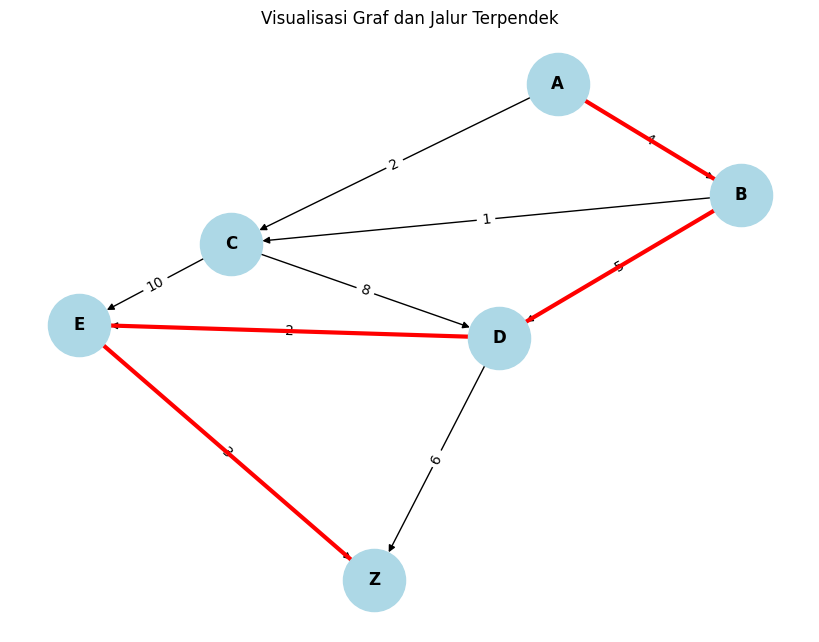

In [40]:
# Definisi graf
graph = {
  'A': {'B': 4, 'C': 2},
  'B': {'C': 1, 'D': 5},
  'C': {'D': 8, 'E': 10},
  'D': {'E': 2, 'Z': 6},
  'E': {'Z': 3},
  'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node} : {distances [end_node] }")
print(f"Jalur: {'-'.join (shortest_path) }")

# Visualisasi
visualize_graph (graph, path=shortest_path)

**Penjelasan:**
* Graf diinisialisasi dalam bentuk dictionary, lalu algoritma dijalankan dari simpul 'A' ke
'Z'. Hasilnya ditampilkan dalam bentuk teks dan digambarkan dalam bentuk graf.
Mahasiswa dapat mengubah isi graf untuk menguji pemahaman mereka terhadap
perubahan jalur terpendek.



---
# **LATIHAN / TUGAS**
1. Modifikasi graf agar memiliki siklus dan ulangi visualisasinya.
2. Tambahkan simpul baru dan lihat bagaimana jalur terpendek berubah.
3. Ganti tata letak graf dengan *pos = nx.circular_layout (G)* atau
*kamada_kawai_layout*.

**1. Modifikasi graf agar memiliki siklus dan ulangi visualisasinya.**

Jarak dari A ke Z : 14
Jalur: A-B-D-E-Z


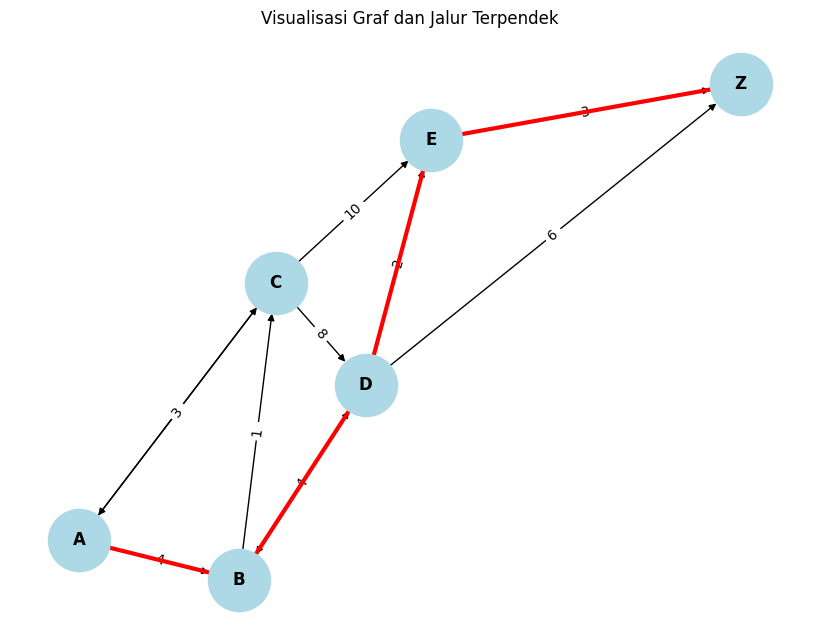

In [42]:
# Definisi graf
graph = {
  'A': {'B': 4, 'C': 2},
  'B': {'C': 1, 'D': 5},
  'C': {'D': 8, 'E': 10, 'A': 3}, # 1.) Siklus terbentuk di sini berjalan dengan (C -> A)
  'D': {'E': 2, 'Z': 6, 'B': 4},  # 1.) D juga mempunyai siklus ke B (D -> B)
  'E': {'Z': 3},
  'Z': {}                         # Tujuan Akhir
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node} : {distances [end_node] }")
print(f"Jalur: {'-'.join (shortest_path) }")

# Visualisasi
visualize_graph (graph, path=shortest_path)

**2. Tambahkan simpul baru dan lihat bagaimana jalur terpendek berubah.**

Jarak dari A ke Z : 7
Jalur: A-F-Z


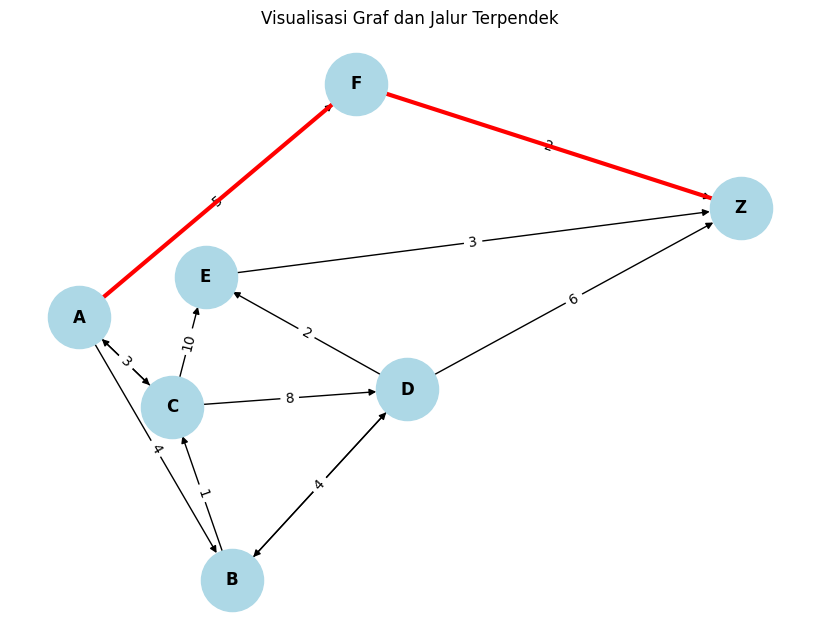

In [47]:
# Definisi graf
graph = {
  'A': {'B': 4, 'C': 2, 'F': 5},  # 2.) Menghubungkan ke simpul F agar jalur terpendek terbentuk
  'B': {'C': 1, 'D': 5},
  'C': {'D': 8, 'E': 10, 'A': 3}, # 1.) Siklus terbentuk di sini berjalan dengan (C -> A)
  'D': {'E': 2, 'Z': 6, 'B': 4},  # 1.) D juga mempunyai siklus ke B (D -> B)
  'E': {'Z': 3},
  'F': {'Z': 2},                  # 2.) Membuat Simpul Baru yang memiliki jalur (A -> F -> Z)
  'Z': {}                         # Tujuan Akhir
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node} : {distances [end_node] }")
print(f"Jalur: {'-'.join (shortest_path) }")

# Visualisasi
visualize_graph (graph, path=shortest_path)

**3. Ganti tata letak graf dengan *pos = nx.circular_layout (G)* atau
*kamada_kawai_layout*.**

Jarak dari A ke Z : 7
Jalur: A-F-Z


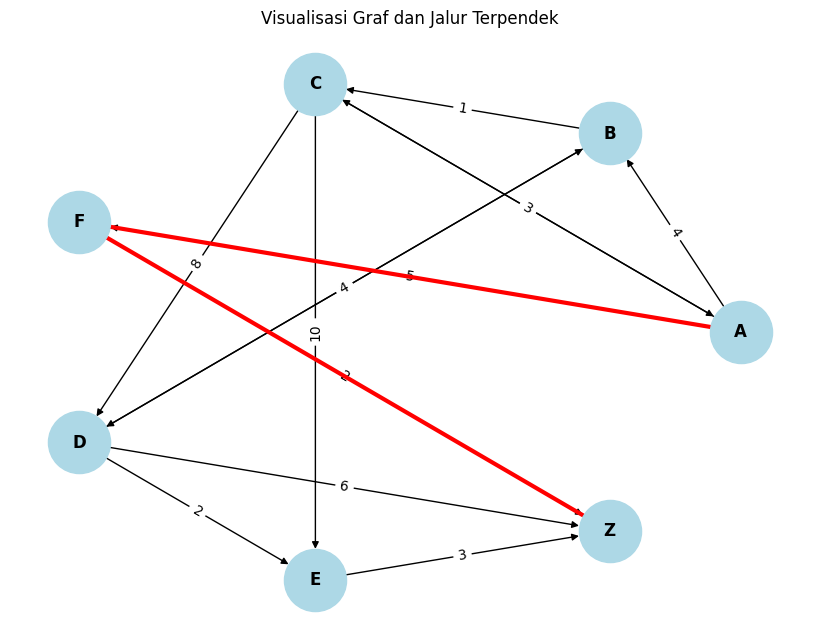

In [49]:
# Definisi graf
graph = {
  'A': {'B': 4, 'C': 2, 'F': 5},  # 2.) Menghubungkan ke simpul F agar jalur terpendek terbentuk
  'B': {'C': 1, 'D': 5},
  'C': {'D': 8, 'E': 10, 'A': 3}, # 1.) Siklus terbentuk di sini berjalan dengan (C -> A)
  'D': {'E': 2, 'Z': 6, 'B': 4},  # 1.) D juga mempunyai siklus ke B (D -> B)
  'E': {'Z': 3},
  'F': {'Z': 2},                  # 2.) Membuat Simpul Baru yang memiliki jalur (A -> F -> Z)
  'Z': {}                         # Tujuan Akhir
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths (graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path (previous, end_node)
print (f"Jarak dari {start_node} ke {end_node} : {distances [end_node] }")
print(f"Jalur: {'-'.join (shortest_path) }")

# Visualisasi
visualize_graph (graph, path=shortest_path)